# US Airline Flight Routes and Fares Market analysis(1993-2024)
--------------------------------
### Date: Feb 7, 2026
### Author: Zakarias Musa
--------------------------------
#### Description: Explore US domestic airline data to uncover patterns in pricing, demand, competition, and market structure.
#### Methodology: Robust handling of skewed data, proper temporal analysis, and justifiable insights without misrepresenting outliers.
--------------------------------

In [46]:
# Libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [47]:
airline_data=pd.read_csv("/Users/napi/Documents/us_airline_data/US Airline Flight Routes and Fares 1993-2024.csv")
airline_data.head(5) # return the first five rows

/var/folders/k6/8820r8z566j4ptgs9g1rxph80000gp/T/ipykernel_5084/2829332637.py:1: DtypeWarning: Columns (20,21) have mixed types. Specify dtype option on import or set low_memory=False.
  airline_data=pd.read_csv("/Users/napi/Documents/us_airline_data/US Airline Flight Routes and Fares 1993-2024.csv")


,tbl,Year,quarter,citymarketid_1,citymarketid_2,city1,city2,airportid_1,airportid_2,airport_1,...,fare,carrier_lg,large_ms,fare_lg,carrier_low,lf_ms,fare_low,Geocoded_City1,Geocoded_City2,tbl1apk
0,Table1a,2021,3,30135,33195,"Allentown/Bethlehem/Easton, PA","Tampa, FL (Metropolitan Area)",10135,14112,ABE,...,81.43,G4,1.0000,81.43,G4,1.0000,81.43,NaN,NaN,202131013514112ABEPIE
1,Table1a,2021,3,30135,33195,"Allentown/Bethlehem/Easton, PA","Tampa, FL (Metropolitan Area)",10135,15304,ABE,...,208.93,DL,0.4659,219.98,UA,0.1193,154.11,NaN,NaN,202131013515304ABETPA
2,Table1a,2021,3,30140,30194,"Albuquerque, NM","Dallas/Fort Worth, TX",10140,11259,ABQ,...,184.56,WN,0.9968,184.44,WN,0.9968,184.44,NaN,NaN,202131014011259ABQDAL
3,Table1a,2021,3,30140,30194,"Albuquerque, NM","Dallas/Fort Worth, TX",10140,11298,ABQ,...,182.64,AA,0.9774,183.09,AA,0.9774,183.09,NaN,NaN,202131014011298ABQDFW
4,Table1a,2021,3,30140,30466,"Albuquerque, NM","Phoenix, AZ",10140,14107,ABQ,...,177.11,WN,0.6061,184.49,AA,0.3939,165.77,NaN,NaN,202131014014107ABQPHX


- Our raw data has been successfully loaded to our environment to be analysed

In [48]:
airline_data.shape # Check the shape of the data

(245955, 23)

In [49]:
airline_data.info() #check to understand the structure, data types, and any potential cleaning issues

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 245955 entries, 0 to 245954
Data columns (total 23 columns):
 #   Column          Non-Null Count   Dtype  
---  ------          --------------   -----  
 0   tbl             245955 non-null  object 
 1   Year            245955 non-null  int64  
 2   quarter         245955 non-null  int64  
 3   citymarketid_1  245955 non-null  int64  
 4   citymarketid_2  245955 non-null  int64  
 5   city1           245955 non-null  object 
 6   city2           245955 non-null  object 
 7   airportid_1     245955 non-null  int64  
 8   airportid_2     245955 non-null  int64  
 9   airport_1       245955 non-null  object 
 10  airport_2       245955 non-null  object 
 11  nsmiles         245955 non-null  int64  
 12  passengers      245955 non-null  int64  
 13  fare            245955 non-null  float64
 14  carrier_lg      244415 non-null  object 
 15  large_ms        244415 non-null  float64
 16  fare_lg         244415 non-null  float64
 17  carrier_lo

In [50]:
airline_data.describe(include='all')
#spotting outliers, empty strings, and default placeholder values like 0 or unknown.

,tbl,Year,quarter,citymarketid_1,citymarketid_2,city1,city2,airportid_1,airportid_2,airport_1,...,fare,carrier_lg,large_ms,fare_lg,carrier_low,lf_ms,fare_low,Geocoded_City1,Geocoded_City2,tbl1apk
count,245955,245955.000000,245955.000000,245955.000000,245955.000000,245955,245955,245955.000000,245955.000000,245955,...,245955.000000,244415,244415.000000,244415.000000,244343,244343.000000,244343.000000,206749,206749,245955
unique,2,NaN,NaN,NaN,NaN,141,128,NaN,NaN,187,...,NaN,67,NaN,NaN,71,NaN,NaN,238,207,245955
top,Table 1a,NaN,NaN,NaN,NaN,"Los Angeles, CA (Metropolitan Area)","New York City, NY (Metropolitan Area)",NaN,NaN,ORD,...,NaN,WN,NaN,NaN,WN,NaN,NaN,"Los Angeles, CA (Metropolitan Area)\n(34.05223...","New York City, NY (Metropolitan Area)\n(40.123...",202131013514112ABEPIE
freq,200897,NaN,NaN,NaN,NaN,26055,36913,NaN,NaN,8819,...,NaN,58999,NaN,NaN,56027,NaN,NaN,21028,30688,1
mean,NaN,2008.524124,2.479153,31556.430201,32180.117086,NaN,NaN,12437.099986,13249.889525,NaN,...,218.979587,NaN,0.665252,218.710963,NaN,0.450438,190.675939,NaN,NaN,NaN
std,NaN,8.703364,1.122149,1089.872880,1232.464184,NaN,NaN,1431.665257,1425.810159,NaN,...,82.372486,NaN,0.224635,84.674363,NaN,0.332669,73.577694,NaN,NaN,NaN
min,NaN,1993.000000,1.000000,30135.000000,30189.000000,NaN,NaN,10135.000000,10466.000000,NaN,...,50.000000,NaN,0.003800,50.000000,NaN,0.010000,50.000000,NaN,NaN,NaN
25%,NaN,2001.000000,1.000000,30721.000000,30994.000000,NaN,NaN,11193.000000,12197.000000,NaN,...,164.620000,NaN,0.480000,161.500000,NaN,0.158000,140.060000,NaN,NaN,NaN
50%,NaN,2008.000000,2.000000,31423.000000,32211.000000,NaN,NaN,12266.000000,13303.000000,NaN,...,209.320000,NaN,0.652400,208.030000,NaN,0.360000,181.630000,NaN,NaN,NaN
75%,NaN,2016.000000,3.000000,32467.000000,33192.000000,NaN,NaN,13487.000000,14679.000000,NaN,...,262.890000,NaN,0.871900,263.640000,NaN,0.750000,230.040000,NaN,NaN,NaN


In [51]:
airline_data.isnull().sum().sort_values(ascending=False) 
# quick snapshot of missing data, sorted so that the columns with the most nulls are on top

Geocoded_City2    39206
Geocoded_City1    39206
fare_low           1612
lf_ms              1612
carrier_low        1612
fare_lg            1540
large_ms           1540
carrier_lg         1540
tbl                   0
passengers            0
fare                  0
nsmiles               0
Year                  0
airport_2             0
airport_1             0
airportid_2           0
airportid_1           0
city2                 0
city1                 0
citymarketid_2        0
citymarketid_1        0
quarter               0
tbl1apk               0
dtype: int64

- The raw data has a missing values in some of its numerical and categorical columns, so that need to be cleaned for the sake of a cleaned analsis workflow and also to avoid misleaded interpretation.

In [52]:
airline_data0=airline_data.copy() # create a copy of the raw data to avoid data lose

In [53]:
airline_data0[["fare_low","fare_lg","lf_ms"]]=airline_data0[["fare_low","fare_lg","lf_ms"]].fillna('median')
# fill the three columns with a median value

- The columns fare_low, fare_lg, and lf_ms were imputed using the median because these variables are continuous and likely skewed. The median is robust to outliers and extreme values (common in fare and load factor data), ensuring that the imputation does not distort the overall distribution.

In [54]:
airline_data0[["carrier_lg","carrier_low","large_ms"]]=airline_data0[["carrier_lg","carrier_low","large_ms"]].fillna('not_reported')
# fill the three categorical column with 'not reported' to retain records while clearly marking unknown entries.

- The categorical columns carrier_lg, carrier_low, and large_ms were filled with "not_reported" to indicate missing information. This preserves the dataset’s structure without introducing misleading values, allowing analysis to handle unknown or missing categories explicitly.

In [55]:
airline_data0.drop(columns=["Geocoded_City1"], inplace=True)
airline_data0.drop(columns=["Geocoded_City2"], inplace=True)
#drop the the columns with null values and has no any contribution to the analysis
airline_data0.head(5)#quick check if the columns are successfully removed from the copy data

,tbl,Year,quarter,citymarketid_1,citymarketid_2,city1,city2,airportid_1,airportid_2,airport_1,...,nsmiles,passengers,fare,carrier_lg,large_ms,fare_lg,carrier_low,lf_ms,fare_low,tbl1apk
0,Table1a,2021,3,30135,33195,"Allentown/Bethlehem/Easton, PA","Tampa, FL (Metropolitan Area)",10135,14112,ABE,...,970,180,81.43,G4,1.0,81.43,G4,1.0,81.43,202131013514112ABEPIE
1,Table1a,2021,3,30135,33195,"Allentown/Bethlehem/Easton, PA","Tampa, FL (Metropolitan Area)",10135,15304,ABE,...,970,19,208.93,DL,0.4659,219.98,UA,0.1193,154.11,202131013515304ABETPA
2,Table1a,2021,3,30140,30194,"Albuquerque, NM","Dallas/Fort Worth, TX",10140,11259,ABQ,...,580,204,184.56,WN,0.9968,184.44,WN,0.9968,184.44,202131014011259ABQDAL
3,Table1a,2021,3,30140,30194,"Albuquerque, NM","Dallas/Fort Worth, TX",10140,11298,ABQ,...,580,264,182.64,AA,0.9774,183.09,AA,0.9774,183.09,202131014011298ABQDFW
4,Table1a,2021,3,30140,30466,"Albuquerque, NM","Phoenix, AZ",10140,14107,ABQ,...,328,398,177.11,WN,0.6061,184.49,AA,0.3939,165.77,202131014014107ABQPHX


In [56]:
airline_data0.isnull().sum().sort_values(ascending=False) # Recheck if there exist any null values left after clean up

tbl               0
nsmiles           0
fare_low          0
lf_ms             0
carrier_low       0
fare_lg           0
large_ms          0
carrier_lg        0
fare              0
passengers        0
airport_2         0
Year              0
airport_1         0
airportid_2       0
airportid_1       0
city2             0
city1             0
citymarketid_2    0
citymarketid_1    0
quarter           0
tbl1apk           0
dtype: int64

- The null values are successfully handled all over the existing raws

In [57]:
airline_data0['tbl'].unique #check for strange values

<bound method Series.unique of 0         Table1a
1         Table1a
2         Table1a
3         Table1a
4         Table1a
           ...   
245950    Table1a
245951    Table1a
245952    Table1a
245953    Table1a
245954    Table1a
Name: tbl, Length: 245955, dtype: object>

In [58]:
airline_data0.drop(columns=["tbl"],inplace=True) # the "tbl" column dropped since it has a constant value in the entire raw
airline_data0.head(5) # shows the first five raws to confirm the "tbl" column was successfully dropped

,Year,quarter,citymarketid_1,citymarketid_2,city1,city2,airportid_1,airportid_2,airport_1,airport_2,nsmiles,passengers,fare,carrier_lg,large_ms,fare_lg,carrier_low,lf_ms,fare_low,tbl1apk
0,2021,3,30135,33195,"Allentown/Bethlehem/Easton, PA","Tampa, FL (Metropolitan Area)",10135,14112,ABE,PIE,970,180,81.43,G4,1.0,81.43,G4,1.0,81.43,202131013514112ABEPIE
1,2021,3,30135,33195,"Allentown/Bethlehem/Easton, PA","Tampa, FL (Metropolitan Area)",10135,15304,ABE,TPA,970,19,208.93,DL,0.4659,219.98,UA,0.1193,154.11,202131013515304ABETPA
2,2021,3,30140,30194,"Albuquerque, NM","Dallas/Fort Worth, TX",10140,11259,ABQ,DAL,580,204,184.56,WN,0.9968,184.44,WN,0.9968,184.44,202131014011259ABQDAL
3,2021,3,30140,30194,"Albuquerque, NM","Dallas/Fort Worth, TX",10140,11298,ABQ,DFW,580,264,182.64,AA,0.9774,183.09,AA,0.9774,183.09,202131014011298ABQDFW
4,2021,3,30140,30466,"Albuquerque, NM","Phoenix, AZ",10140,14107,ABQ,PHX,328,398,177.11,WN,0.6061,184.49,AA,0.3939,165.77,202131014014107ABQPHX


In [59]:
# Remove anything inside parentheses like "(Metropolitan Area)"
# Keep them creates duplicate labels for the same market
# "Tampa, Fl (Metropolitan Area)" is not same with "Tampa, Fl"
# For analysis, these must be the SAME market

airline_data0['city1'] = airline_data0['city1'].str.replace(r'\s*\(.*?\)', '', regex=True)
airline_data0['city2'] = airline_data0['city2'].str.replace(r'\s*\(.*?\)', '', regex=True)



In [60]:
# Split the market name from the state using the LAST comma 
airline_data0[['origin_market', 'origin_state']] = airline_data0['city1'].str.rsplit(',', n=1, expand=True)
airline_data0[['dest_market', 'dest_state']] = airline_data0['city2'].str.rsplit(',', n=1, expand=True)
airline_data0

,Year,quarter,citymarketid_1,citymarketid_2,city1,city2,airportid_1,airportid_2,airport_1,airport_2,...,large_ms,fare_lg,carrier_low,lf_ms,fare_low,tbl1apk,origin_market,origin_state,dest_market,dest_state
0,2021,3,30135,33195,"Allentown/Bethlehem/Easton, PA","Tampa, FL",10135,14112,ABE,PIE,...,1.0,81.43,G4,1.0,81.43,202131013514112ABEPIE,Allentown/Bethlehem/Easton,PA,Tampa,FL
1,2021,3,30135,33195,"Allentown/Bethlehem/Easton, PA","Tampa, FL",10135,15304,ABE,TPA,...,0.4659,219.98,UA,0.1193,154.11,202131013515304ABETPA,Allentown/Bethlehem/Easton,PA,Tampa,FL
2,2021,3,30140,30194,"Albuquerque, NM","Dallas/Fort Worth, TX",10140,11259,ABQ,DAL,...,0.9968,184.44,WN,0.9968,184.44,202131014011259ABQDAL,Albuquerque,NM,Dallas/Fort Worth,TX
3,2021,3,30140,30194,"Albuquerque, NM","Dallas/Fort Worth, TX",10140,11298,ABQ,DFW,...,0.9774,183.09,AA,0.9774,183.09,202131014011298ABQDFW,Albuquerque,NM,Dallas/Fort Worth,TX
4,2021,3,30140,30466,"Albuquerque, NM","Phoenix, AZ",10140,14107,ABQ,PHX,...,0.6061,184.49,AA,0.3939,165.77,202131014014107ABQPHX,Albuquerque,NM,Phoenix,AZ
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
245950,2024,1,35412,31703,"Knoxville, TN","New York City, NY",15412,12953,TYS,LGA,...,0.7503,287.44,AA,0.2359,248.46,202411541212953TYSLGA,Knoxville,TN,New York City,NY
245951,2024,1,35412,32467,"Knoxville, TN","Miami, FL",15412,11697,TYS,FLL,...,0.8255,114.45,G4,0.8255,114.45,202411541211697TYSFLL,Knoxville,TN,Miami,FL
245952,2024,1,35412,32467,"Knoxville, TN","Miami, FL",15412,13303,TYS,MIA,...,0.8057,321.92,AA,0.8057,321.92,202411541213303TYSMIA,Knoxville,TN,Miami,FL
245953,2024,1,35412,33195,"Knoxville, TN","Tampa, FL",15412,14112,TYS,PIE,...,1.0,95.65,G4,1.0,95.65,202411541214112TYSPIE,Knoxville,TN,Tampa,FL


- Split the market name from the state using the LAST comma as some markets contain multiple cities separated by commas
e.g. "Allentown,Bethlehem,Easton, Pa"

In [61]:
# Clean the market names
# Remove extra spaces from messy input data
# Standardize capitalization for grouping
# Prevent issues like: "los angeles" , "Los Angeles" , "LOS ANGELES"

for col in ['origin_market', 'dest_market']:
    airline_data0[col] = airline_data0[col].str.strip().str.title()


In [62]:
# Clean and standardize state codes
for col in ['origin_state', 'dest_state']:
    airline_data0[col] = airline_data0[col].str.strip().str.upper()
airline_data0

,Year,quarter,citymarketid_1,citymarketid_2,city1,city2,airportid_1,airportid_2,airport_1,airport_2,...,large_ms,fare_lg,carrier_low,lf_ms,fare_low,tbl1apk,origin_market,origin_state,dest_market,dest_state
0,2021,3,30135,33195,"Allentown/Bethlehem/Easton, PA","Tampa, FL",10135,14112,ABE,PIE,...,1.0,81.43,G4,1.0,81.43,202131013514112ABEPIE,Allentown/Bethlehem/Easton,PA,Tampa,FL
1,2021,3,30135,33195,"Allentown/Bethlehem/Easton, PA","Tampa, FL",10135,15304,ABE,TPA,...,0.4659,219.98,UA,0.1193,154.11,202131013515304ABETPA,Allentown/Bethlehem/Easton,PA,Tampa,FL
2,2021,3,30140,30194,"Albuquerque, NM","Dallas/Fort Worth, TX",10140,11259,ABQ,DAL,...,0.9968,184.44,WN,0.9968,184.44,202131014011259ABQDAL,Albuquerque,NM,Dallas/Fort Worth,TX
3,2021,3,30140,30194,"Albuquerque, NM","Dallas/Fort Worth, TX",10140,11298,ABQ,DFW,...,0.9774,183.09,AA,0.9774,183.09,202131014011298ABQDFW,Albuquerque,NM,Dallas/Fort Worth,TX
4,2021,3,30140,30466,"Albuquerque, NM","Phoenix, AZ",10140,14107,ABQ,PHX,...,0.6061,184.49,AA,0.3939,165.77,202131014014107ABQPHX,Albuquerque,NM,Phoenix,AZ
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
245950,2024,1,35412,31703,"Knoxville, TN","New York City, NY",15412,12953,TYS,LGA,...,0.7503,287.44,AA,0.2359,248.46,202411541212953TYSLGA,Knoxville,TN,New York City,NY
245951,2024,1,35412,32467,"Knoxville, TN","Miami, FL",15412,11697,TYS,FLL,...,0.8255,114.45,G4,0.8255,114.45,202411541211697TYSFLL,Knoxville,TN,Miami,FL
245952,2024,1,35412,32467,"Knoxville, TN","Miami, FL",15412,13303,TYS,MIA,...,0.8057,321.92,AA,0.8057,321.92,202411541213303TYSMIA,Knoxville,TN,Miami,FL
245953,2024,1,35412,33195,"Knoxville, TN","Tampa, FL",15412,14112,TYS,PIE,...,1.0,95.65,G4,1.0,95.65,202411541214112TYSPIE,Knoxville,TN,Tampa,FL


In [63]:
airline_data0.duplicated() #check if there is a duplicated values

0         False
1         False
2         False
3         False
4         False
          ...  
245950    False
245951    False
245952    False
245953    False
245954    False
Length: 245955, dtype: bool

In [64]:
airline_data0 = airline_data0.rename(columns={
    'Year': 'year',
    'citymarketid_1': 'origin_market_id',
    'citymarketid_2': 'destination_market_id',
    'airport_1': 'origin_airport',
    'airport_2': 'destination_airport',
    'airportid_1': 'origin_airport_id',
    'airportid_2': 'destination_airport_id',
    'nsmiles': 'distance_miles',
    'passengers': 'passenger_count',
    'fare': 'average_fare',
    'carrier_lg': 'largest_carrier',
    'large_ms': 'largest_carrier_market_share',
    'fare_lg': 'largest_carrier_fare',
    'carrier_low': 'lowest_fare_carrier',
    'fare_low': 'lowest_carrier_fare',
    'lf_ms': 'market_load_factor',
    'tbl1apk': 'record_id',
    'origin_market': 'origin_market_name',
    'dest_market': 'destination_market_name'
})

# Once created the cleaned ones drop raw city columns as they are redundant and misleading
airline_data0 = airline_data0.drop(columns=['city1', 'city2'])



In [65]:
airline_data0.columns # A glance, the existing columns

Index(['year', 'quarter', 'origin_market_id', 'destination_market_id',
       'origin_airport_id', 'destination_airport_id', 'origin_airport',
       'destination_airport', 'distance_miles', 'passenger_count',
       'average_fare', 'largest_carrier', 'largest_carrier_market_share',
       'largest_carrier_fare', 'lowest_fare_carrier', 'market_load_factor',
       'lowest_carrier_fare', 'record_id', 'origin_market_name',
       'origin_state', 'destination_market_name', 'dest_state'],
      dtype='object')

In [66]:
#changed to the period as we don't know the exact day other than the quarter to convert it to datetime
airline_data0['year_quarter'] = pd.PeriodIndex(
    year=airline_data0['year'],
    quarter=airline_data0['quarter'],
    freq='Q'
)
airline_data0['year_quarter'].dtype #check the data type after conversion to period

/var/folders/k6/8820r8z566j4ptgs9g1rxph80000gp/T/ipykernel_5084/3513533291.py:2: FutureWarning: Constructing PeriodIndex from fields is deprecated. Use PeriodIndex.from_fields instead.
  airline_data0['year_quarter'] = pd.PeriodIndex(


period[Q-DEC]

In [67]:
airline_data0[['distance_miles', 'passenger_count',
       'average_fare','largest_carrier', 'largest_carrier_market_share',
       'largest_carrier_fare', 'lowest_fare_carrier', 'market_load_factor',
       'lowest_carrier_fare']].describe(include="all") 
# Inspect the existance of possible outliers on specific numerical columns,  
# top values, and frequency for categorical columns

,distance_miles,passenger_count,average_fare,largest_carrier,largest_carrier_market_share,largest_carrier_fare,lowest_fare_carrier,market_load_factor,lowest_carrier_fare
count,245955.000000,245955.000000,245955.000000,245955,245955.0,245955,245955,245955.0,245955
unique,NaN,NaN,NaN,68,7368.0,37509,72,9688.0,32284
top,NaN,NaN,NaN,WN,1.0,median,WN,1.0,median
freq,NaN,NaN,NaN,58999,13803.0,1540,56027,13803.0,1612
mean,1189.812319,299.476795,218.979587,NaN,NaN,NaN,NaN,NaN,NaN
std,703.143472,511.389486,82.372486,NaN,NaN,NaN,NaN,NaN,NaN
min,109.000000,0.000000,50.000000,NaN,NaN,NaN,NaN,NaN,NaN
25%,626.000000,21.000000,164.620000,NaN,NaN,NaN,NaN,NaN,NaN
50%,1023.000000,113.000000,209.320000,NaN,NaN,NaN,NaN,NaN,NaN
75%,1736.000000,339.000000,262.890000,NaN,NaN,NaN,NaN,NaN,NaN


### Outlier Analysis – Average Fare

Airline fare distributions are typically **right-skewed**, with a small number of
routes exhibiting extremely high prices due to factors such as low competition,
long distances, or limited demand.

Rather than removing these observations, outliers are **flagged and analyzed
separately** to preserve meaningful market behavior and avoid biasing the analysis.


<Axes: >

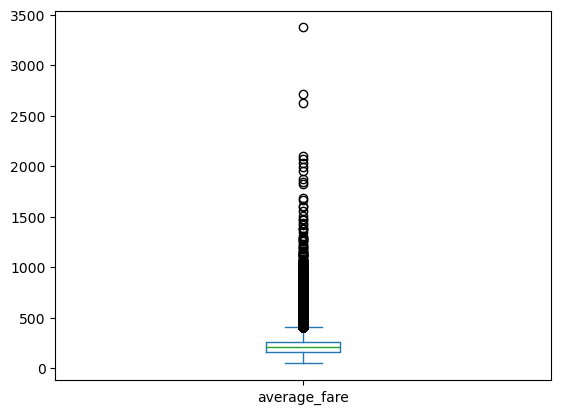

In [68]:
# Boxplot is used because:
# It clearly shows median, IQR, and extreme values
# It is robust to skewed distributions
# It visually aligns with the IQR method
airline_data0['average_fare'].plot.box()

### IQR Method for Outlier Detection

Outliers were flagged using the IQR method and analyzed separately, as they represent a small but economically meaningful subset of airline markets rather than erroneous observations.



In [69]:
# Calculate quartiles for average fare
Q1 = airline_data0['average_fare'].quantile(0.25)
Q3 = airline_data0['average_fare'].quantile(0.75)

# IQR captures the spread of the middle 50% of fares
IQR = Q3 - Q1

# Define both bounds explicitly for methodological correctness
lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

# Flag outliers instead of removing them
airline_data0['is_fare_outlier'] = (
    (airline_data0['average_fare'] < lower_bound) |
    (airline_data0['average_fare'] > upper_bound)
)



In [70]:
airline_data0['is_fare_outlier'].value_counts()

is_fare_outlier
False    241198
True       4757
Name: count, dtype: int64

### Interpretation

  Only 4,757 are flagged as fare outliers out of 245,955, indicating that extreme fares are rare but meaningful. This confirms that the IQR method is not over-flagging and that most airline fares fall within a stable pricing range. The small proportion of outliers suggests these values likely represent structurally different markets (e.g., long-distance routes, low-competition markets, or premium pricing routes) rather than data errors. Therefore, retaining and analyzing these observations separately is justified to avoid biasing average fare and demand analyses.


### Insight from Average fare outlier analysis
The fact that only ~2% of routes exhibit extreme fares suggests that airline pricing is largely competitive for most markets, while a very small subset drives disproportionate price extremes, likely due to monopoly power, limited demand, or operational constraints. These routes are therefore key leverage points for understanding fare inflation rather than noise to be removed.

### Outlier Analysis - Passenger Count

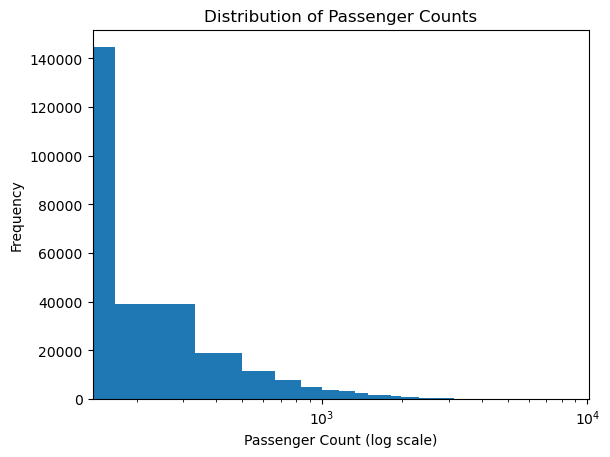

In [71]:
# Histogram shows full distribution shape
# Log scale is used because passenger counts are heavily right-skewed
# This prevents high-demand routes from compressing the majority
plt.hist(airline_data0['passenger_count'], bins=50)
plt.xscale('log')  # Log scale reveals structure in skewed distributions
plt.xlabel("Passenger Count (log scale)")
plt.ylabel("Frequency")
plt.title("Distribution of Passenger Counts")
plt.show()



In [72]:
# IQR is chosen because passenger counts are not normally distributed
# and are often dominated by a small number of very high-demand routes

Q1 = airline_data0['passenger_count'].quantile(0.25)
Q3 = airline_data0['passenger_count'].quantile(0.75)

# IQR represents the typical demand range
IQR = Q3 - Q1

# Define standard statistical bounds
lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

# Flag passenger outliers instead of removing them
# These likely represent peak-demand routes
airline_data0['is_passenger_outlier'] = (
    (airline_data0['passenger_count'] < lower_bound) |
    (airline_data0['passenger_count'] > upper_bound)
)


In [73]:
# Check proportion of passenger outliers
airline_data0['is_passenger_outlier'].value_counts()


is_passenger_outlier
False    221475
True      24480
Name: count, dtype: int64

#### Interpretation
Approximately 10% of routes exhibit extreme passenger volumes, indicating a distinct high-demand market segment. Unlike fare outliers (~2%), passenger outliers are relatively common, suggesting that demand concentration is a structural feature of the airline network rather than rare anomalies.

### The insight from passengers outlier analysis
 Passenger traffic is highly concentrated, with a small but substantial subset of routes driving a disproportionate share of total demand.

# Part 1

In [74]:
# Convert market share to numeric
# coerce errors turns invalid strings into NaN
airline_data0['largest_carrier_market_share'] = pd.to_numeric(
    airline_data0['largest_carrier_market_share'],
    errors='coerce'
)



In [75]:
airline_data0['largest_carrier_market_share'].describe()


count    244415.000000
mean          0.665252
std           0.224635
min           0.003800
25%           0.480000
50%           0.652400
75%           0.871900
max           1.000000
Name: largest_carrier_market_share, dtype: float64

In [76]:
# Bin market share into competition levels
# Create competition levels based on the dominant carrier's market share
airline_data0['competition_level'] = pd.cut(
    airline_data0['largest_carrier_market_share'],
    bins=[0, 0.4, 0.6, 0.8, 1.0],#Using bins avoids assuming linear effects
    labels=['Highly competitive', 'Moderate', 'Low competition', 'Near monopoly'],
    include_lowest=True #Labels turn numbers into market structure language
)
# Normalize fare by distance to remove route-length bias
airline_data0['fare_per_mile'] = (
    airline_data0['average_fare'] / airline_data0['distance_miles']
)

airline_data0['competition_level']

0           Near monopoly
1                Moderate
2           Near monopoly
3           Near monopoly
4         Low competition
               ...       
245950    Low competition
245951      Near monopoly
245952      Near monopoly
245953      Near monopoly
245954           Moderate
Name: competition_level, Length: 245955, dtype: category
Categories (4, object): ['Highly competitive' < 'Moderate' < 'Low competition' < 'Near monopoly']

In [77]:
# Calculate fare per mile for each competition level
# Aggregates fares within each competition regime
# Mean is appropriate because i'm comparing group-level pricing behavior, not individual routes
airline_data0.groupby('competition_level')['fare_per_mile'].mean()



/var/folders/k6/8820r8z566j4ptgs9g1rxph80000gp/T/ipykernel_5084/3512230950.py:4: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  airline_data0.groupby('competition_level')['fare_per_mile'].mean()


competition_level
Highly competitive    0.163071
Moderate              0.221501
Low competition       0.247442
Near monopoly         0.332185
Name: fare_per_mile, dtype: float64

#### Interpretation
- Fare per mile increases consistently as market concentration rises.
- Highly competitive markets average $0.16 per mile, while near-monopoly markets reach $0.33 per mile.
- That is roughly a 2× increase in price per mile from competitive to monopoly conditions.

/var/folders/k6/8820r8z566j4ptgs9g1rxph80000gp/T/ipykernel_5084/3051605615.py:2: FutureWarning: 

The `ci` parameter is deprecated. Use `errorbar=None` for the same effect.

  sns.barplot(


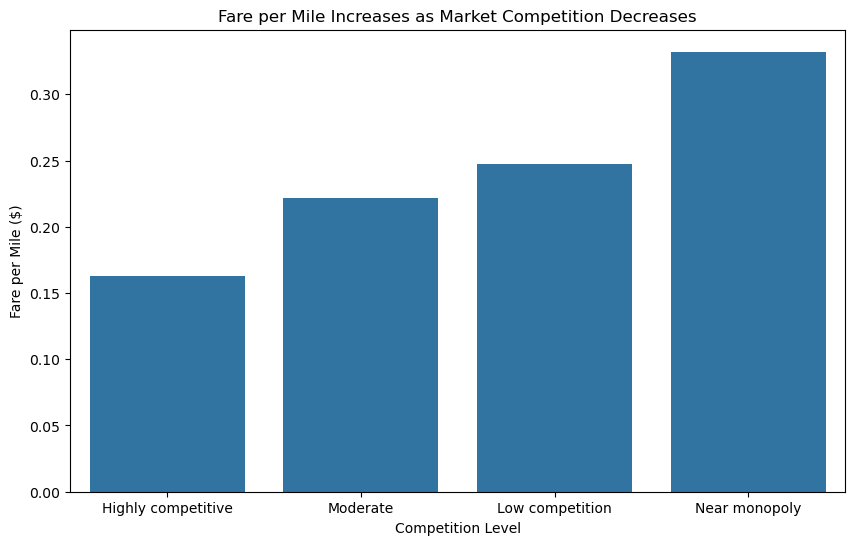

In [78]:
plt.figure(figsize=(10,6))
sns.barplot(
    x='competition_level',
    y='fare_per_mile',
    data=airline_data0,
    ci=None
)

plt.title("Fare per Mile Increases as Market Competition Decreases")
plt.xlabel("Competition Level")
plt.ylabel("Fare per Mile ($)")
plt.show()
# Barplot is used because:
# The independent variable (competition_level) is categorical
# The goal is to compare average fare per mile across groups
# Barplots clearly display group-level central tendency (mean)
# They make monotonic trends easy to see


### Market Competition and Fare Levels insight

As market concentration increases, fare per mile rises steadily, nearly doubling from highly competitive to near-monopoly markets.

This indicates that reduced competition significantly increases pricing power, even after controlling for distance.

# Part 2

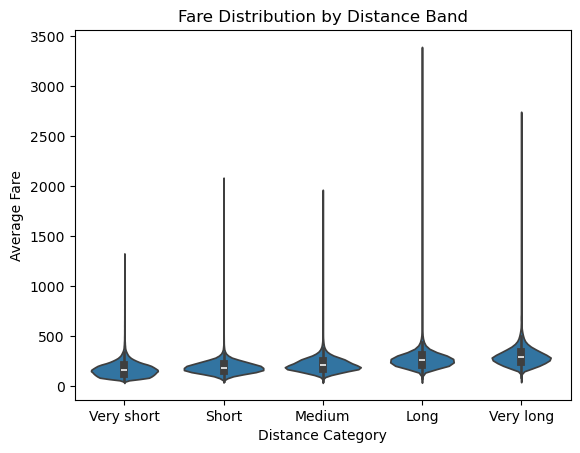

In [79]:
# Create operationally meaningful distance bands
# Reason: fare-distance relationship is non-linear
airline_data0['distance_band'] = pd.cut(
    airline_data0['distance_miles'],
    bins=[0, 500, 1000, 1500, 2500, 4000],
    labels=['Very short', 'Short', 'Medium', 'Long', 'Very long']
)

# Violin plot reveals distribution width, not just central tendency
sns.violinplot(
    x='distance_band',
    y='average_fare',
    data=airline_data0
)

plt.title("Fare Distribution by Distance Band")
plt.xlabel("Distance Category")
plt.ylabel("Average Fare")
plt.show()



While average fares increase with distance, the variance of fares increases much faster than the mean.
This indicates that distance explains baseline costs but fails to explain pricing behavior, especially on long-haul routes.

### Fare vs Distance Insight
Distance influences minimum airfare levels, but pricing flexibility increases sharply with distance.
Long-haul markets exhibit extreme fare dispersion, indicating that factors beyond cost—such as market power, timing, and route exclusivity—dominate pricing decisions.

# Part 3

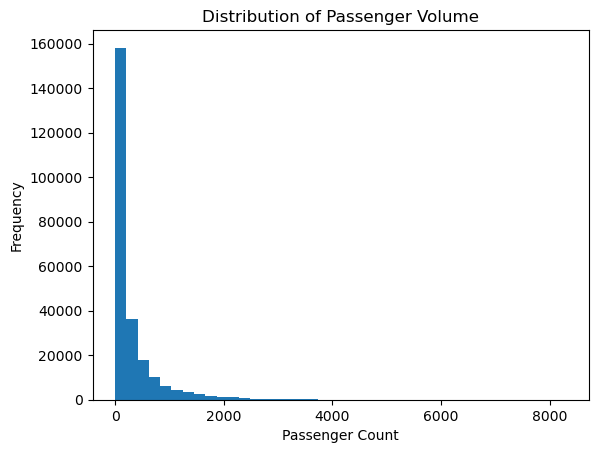

In [80]:
# Inspect passenger volume distribution
# Reason: passenger counts are heavily right-skewed
airline_data0['passenger_count'].plot.hist(bins=40)
plt.title("Distribution of Passenger Volume")
plt.xlabel("Passenger Count")
plt.show()
# histogram was used to see the univariable structure(passenger_count)
# To understand the shape of the distribution
# To check skewness and detect extreme concentration

The histogram shows:
- Passenger volume is heavily right-skewed
- Most routes have low passenger counts
- A small number of routes dominate traffic

Airline markets are highly concentrated in volume.
Average passenger count is misleading due to extreme skewness.

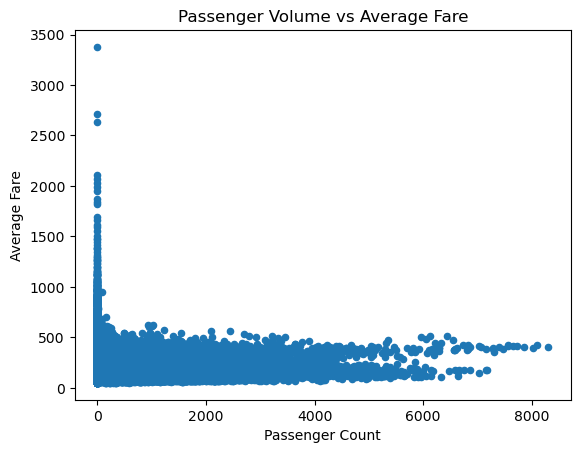

In [81]:
# Scatter used to show the relationship between the two continuous variables,
# To detect patterns, clustering, or structural constraints
# To test whether demand visibly disciplines pricing
# check whether aggregation is even justified
airline_data0.plot.scatter(
    x='passenger_count',
    y='average_fare'
)
plt.title("Passenger Volume vs Average Fare")
plt.xlabel("Passenger Count")
plt.ylabel("Average Fare")
plt.show()



High-volume markets display price compression rather than price minimization. While extreme fares become less frequent as passenger volume increases, fares do not collapse to low levels. This demonstrates that demand constrains extreme pricing but does not discipline fare levels, contradicting the assumption that economies of scale alone drive lower prices.

#### Insight: passenger volume vs fare
- Demand influences fare stability but does not determine fare level.
Airline pricing remains elevated even in high-traffic markets.

# Part 4

In [82]:
airline_data0['market_load_factor'] = pd.to_numeric(
    airline_data0['market_load_factor'],
    errors='coerce'
)
#convert the 'market load factor' values to appropriate numeric value(float)

In [83]:
airline_data0['market_load_factor'].describe() # To explore the statistical summary on market load factor 

count    244343.000000
mean          0.450438
std           0.332669
min           0.010000
25%           0.158000
50%           0.360000
75%           0.750000
max           1.000000
Name: market_load_factor, dtype: float64

In [84]:
# Create efficiency bands based on industry benchmarks
airline_data0['load_band'] = pd.cut(
    airline_data0['market_load_factor'],
    bins=[0, 0.6, 0.7, 0.8, 0.9, 1.0],
    labels=['Very low', 'Low', 'Medium', 'High', 'Very high']
)
airline_data0['load_band'] # shows the binned route-quarter

0         Very high
1          Very low
2         Very high
3         Very high
4          Very low
            ...    
245950     Very low
245951         High
245952         High
245953    Very high
245954     Very low
Name: load_band, Length: 245955, dtype: category
Categories (5, object): ['Very low' < 'Low' < 'Medium' < 'High' < 'Very high']

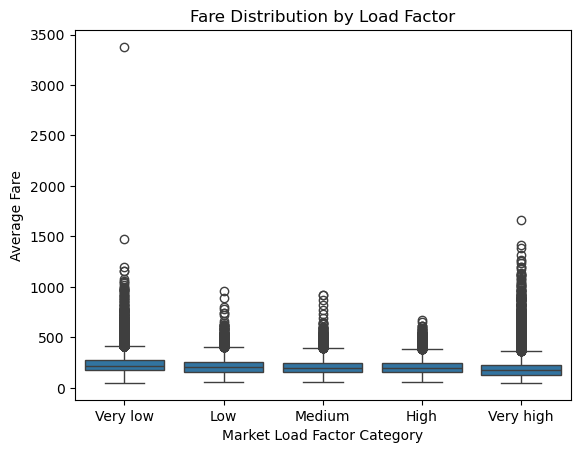

In [85]:
# Boxplot highlights median and spread clearly when the distribution shape is not the focus
# boxplot is better to answer:
# Does median fare change with load factor?
# Does variability shrink when planes are full?
sns.boxplot(
    x='load_band',
    y='average_fare',
    data=airline_data0
)

plt.title("Fare Distribution by Load Factor")
plt.xlabel("Market Load Factor Category")
plt.ylabel("Average Fare")
plt.show()

- Boxplot shows similar median fares across load factor bands.
- High fares occur in every load category
- No strong upward pattern as load increases

From this we can conclude that Load factor does not strongly determine pricing behavior.

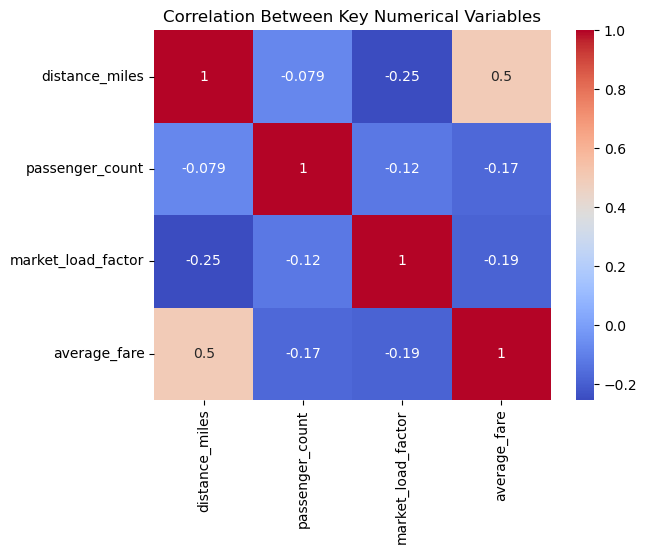

In [86]:
# A correlation analysis(Heatmap) is used only to confirm weak relationships between the two variables
# It quickly shows strength and direction of linear relationships
# Validates whether relationships seen visually are statistically meaningful
# its used to confirm if load factor is actually correlated with fare
numeric_cols = [
    'distance_miles',
    'passenger_count',
    'market_load_factor',
    'average_fare'
]# include the columns which the relationships has to be confirmed

sns.heatmap(
    airline_data0[numeric_cols].corr(),
    annot=True,
    cmap='coolwarm'
)

plt.title("Correlation Between Key Numerical Variables")
plt.show()


 #### Interpretation
- Load factor vs fare: −0.19 (weak, slightly negative)
- Passenger count vs fare: −0.17 (weak)
- Distance vs fare: 0.50 - moderate (baseline cost effect only)


Operational efficiency and demand have weak linear influence on fares.
Distance has moderate effect, but does not fully explain pricing.
Correlation analysis confirms a weak negative relationship between load factor and fare.


#### Combined Insight:

Airline pricing appears weakly constrained by efficiency or demand metrics, suggesting fares are primarily shaped by broader market structure rather than operational pressure.
- Market Load Factor Has Weak Influence on Airfare Levels

# Part 5

### Trend Detection 

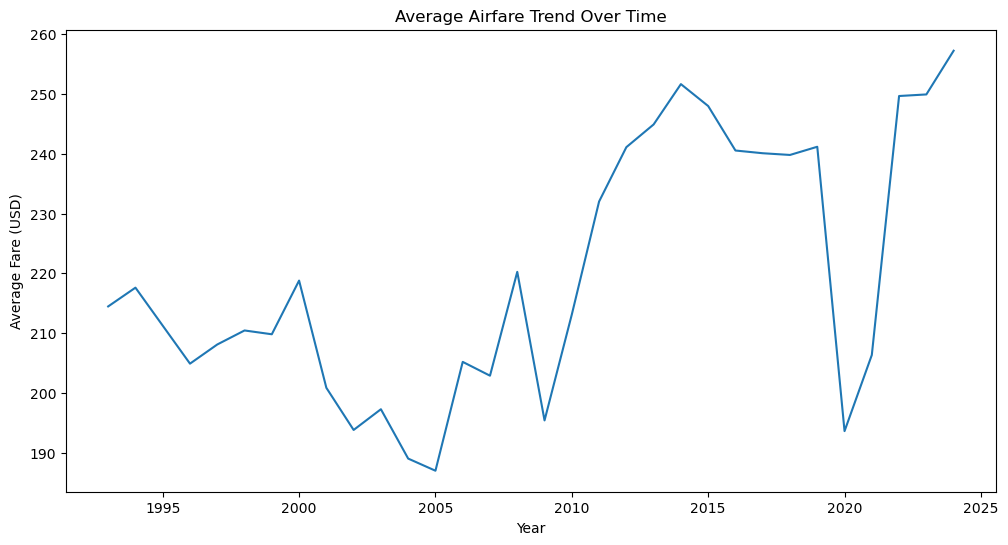

In [87]:
#Average Fare Over Time
#Insight Long-term upward trend 
#Reflects inflation, fuel costs, and market consolidation
fare_trend = airline_data0.groupby('year')['average_fare'].mean()

plt.figure(figsize=(12,6))

plt.plot(fare_trend.index, fare_trend.values)

plt.title("Average Airfare Trend Over Time")

plt.xlabel("Year")

plt.ylabel("Average Fare (USD)")

plt.show()

#### Trend Analysis Interpretation:
- After moderate fluctuations during the 1990s, average airfares declined significantly between 2000 and 2004, reaching their lowest point around 2004–2005.
- Beginning in 2005, fares rebounded strongly and entered a structural growth phase, with a sustained upward trend observed from 2010 onward.
- Between 2012 and 2019, fares stabilized at a higher pricing regime (above $240), indicating possible increased pricing power or rising operating costs.
- A sharp decline occurred in 2020 due to the COVID-19 pandemic, followed by a rapid recovery in subsequent years.
- By 2024, average fares reached their highest observed level, surpassing pre-pandemic peaks.

#### Insight
- The airline market shows long-term fare growth driven by increased pricing power and market concentration, with strong sensitivity to macroeconomic shocks such as COVID-19. Routes with lower competition tend to generate higher revenue efficiency per mile.

#### Business Implication
- Airlines can maximize profitability by strategically focusing on high-demand, low-competition routes while maintaining operational flexibility to withstand external shocks. Route-level competition analysis should guide pricing, expansion, and revenue management decisions.